In [ ]:
import kagglehub

Fetching dataset from `kaggle` using the API KEY

In [ ]:
# Access the API key from Colab secrets
from google.colab import userdata

KAGGLE_API_KEY = userdata.get('KAGGLE_API_KEY')

# Configure kagglehub to use the API key (if needed, otherwise it uses ~/.kaggle/kaggle.json)
# Note: kagglehub typically expects the key to be in ~/.kaggle/kaggle.json,
# but if you need to set it programmatically, you can set environment variables.
# For direct download, it often works by just having the key accessible to the Kaggle API.
# Let's assume for now that if the key is in secrets, it can be accessed.

# Download the dataset using kagglehub.dataset_download
dataset_handle = "yasserh/titanic-dataset"
path = kagglehub.dataset_download(dataset_handle)

print(f"Path to dataset files: {path}")

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt

dataset = pd.read_csv("/kaggle/input/titanic-dataset/Titanic-Dataset.csv")

In [ ]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("information about the dataset: ")
dataset.info()

information about the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The dataset has 891 Rows and 12 Columns 2Float64, 5int64 and 5object dtypes

In [ ]:
print("Using the describe function: ")
dataset.describe()

Using the describe function: 


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
print("Let us look at the null values ")
display(dataset.isnull().sum())

Let us look at the null values 


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


We have null values only in Age and Cabin and 2 in Embarked.

In [ ]:
# Steps as per one of my EDA teacher:
survived = dataset['Survived'].sum()
print(survived)

print("The percentage of passengers survived from the above dataset is: ", (survived/len(dataset))*100, "%")

342
The percentage of passengers survived from the above dataset is:  38.38383838383838 %


In [ ]:
# The Most survived gender.
gender = dataset['Sex']

gender.value_counts()

,count
Sex,
male,577
female,314


In [ ]:
survived = dataset['Survived']

survived.value_counts()

,count
Survived,
0,549
1,342


In [ ]:
group = dataset.groupby('Pclass')['Age'].median()
group

display(dataset['Pclass'].value_counts())

display(dataset['Sex'].value_counts())

# Numerical, Object/Categorical

# Numeric --> Discrete and Continuous.

# We will analyse how to fill in the null values

# THE real EDA>
# for feature in dataset.columns:
  # display(dataset[feature].value_counts())
  # print('\n')

,count
Pclass,
3,491
1,216
2,184


,count
Sex,
male,577
female,314


In [ ]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
numerical_features = [feature for feature in dataset.columns if dataset[feature].dtype != 'object' and feature not in 'PassengerId']

categorical_features = [feature for feature in dataset.columns if dataset[feature].dtype == 'object' and feature not in 'PassengerId']

print(numerical_features)
print(categorical_features)

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [ ]:
# Replace missing values
print(f"Missing values in 'Embarked': {dataset['Embarked'].isnull().sum()}")

# Let us replace the feature 'Embarked' missing values with mode()


Embarked_mode = dataset['Embarked'].mode()[0] # Modes return a series and that why we want the first value therefore [0]
dataset['Embarked'] = dataset['Embarked'].fillna(Embarked_mode)

print(f"Missing values after imputing mode in 'Embarked: {dataset['Embarked'].isnull().sum()}")

Missing values in 'Embarked': 2
Missing values after imputing mode in 'Embarked: 0


In [ ]:
# Median of age as per class

age_per_class = dataset.groupby('Pclass')['Age'].median()
age = age_per_class.to_dict()

print(age)
dataset.groupby('Pclass')['Age'].std()

age_column = dataset['Age']
# 177 values are nan


{1: 37.0, 2: 29.0, 3: 24.0}


In [ ]:
print(f"Missing Age Values Before: {dataset['Age'].isna().sum()}")

dataset['Age'] = dataset['Age'].fillna(dataset.groupby('Pclass')['Age'].transform('median'))

print(f"Missing Age Values After: {dataset['Age'].isna().sum()}")

Missing Age Values Before: 177
Missing Age Values After: 0


In [ ]:
dataset.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
print(f"Missing Cabin Values Before: {dataset['Cabin'].isna().sum()}")

dataset['Cabin'] = dataset['Cabin'].fillna('Unknown Cabin')

print(f"Missing Cabin Values After: {dataset['Cabin'].isna().sum()}")

Missing Cabin Values Before: 687
Missing Cabin Values After: 0


In [ ]:
dataset.info() # Everything is cleared now !

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown Cabin,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown Cabin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown Cabin,S


Let us plot a BoxPlot to find if there are any outliers in numerical_features or not.

If there are outliers, we will use: IQR and Upper Lower Bound method to cap them.

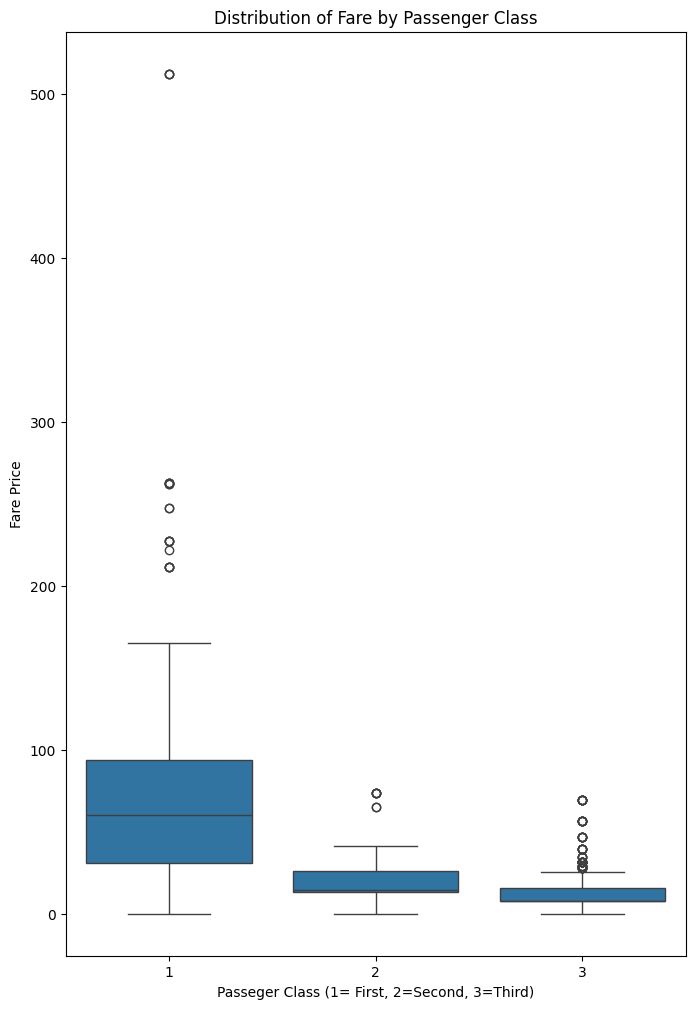

In [ ]:
# DIstribution of Fare, Correlatiob btw Fare and Pclass

plt.figure(figsize=(8,12))
sea.boxplot(dataset, x='Pclass', y='Fare')
plt.title("Distribution of Fare by Passenger Class")
plt.ylabel('Fare Price')
plt.xlabel('Passeger Class (1= First, 2=Second, 3=Third)')
plt.show()

In [ ]:
class_fare_summary = dataset.groupby('Pclass')['Fare'].median()
display("The Summary of Class and Fare of passenger: ", class_fare_summary)

'The Summary of Class and Fare of passenger: '

,Fare
Pclass,
1,60.2875
2,14.2500
3,8.0500


Outliers are clearly visible in Fare Feature of the Dataset. We will use something known as IQR to cap the outlying values. We will use

1. a for loop to iterate over `Pclass` unique values
2. we will generate pclass_data which will have that Class and Fare values
3. Use quantile to generate Q1 and Q3. then find IQR using IQR = Q3 - Q1
4. We will find Upperboound and Lowerbound
5. We will cap the values by comparing with UB nd LB

In [ ]:
dataset_cap = dataset.copy()

for pclass in dataset_cap['Pclass'].unique():
  pclass_data = dataset_cap[dataset_cap['Pclass']==pclass]['Fare']

  Q1 = pclass_data.quantile(0.25)
  Q3 = pclass_data.quantile(0.75)

  IQR = Q3 - Q1

  upper_bound = Q3 + 1.5*IQR
  lower_bound = Q1 - 1.5*IQR

  # Cap values above the upper bound
  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Fare'] > upper_bound), 'Fare'] = upper_bound

  # Corrected: Cap values below the lower bound
  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Fare'] < lower_bound), 'Fare'] = lower_bound

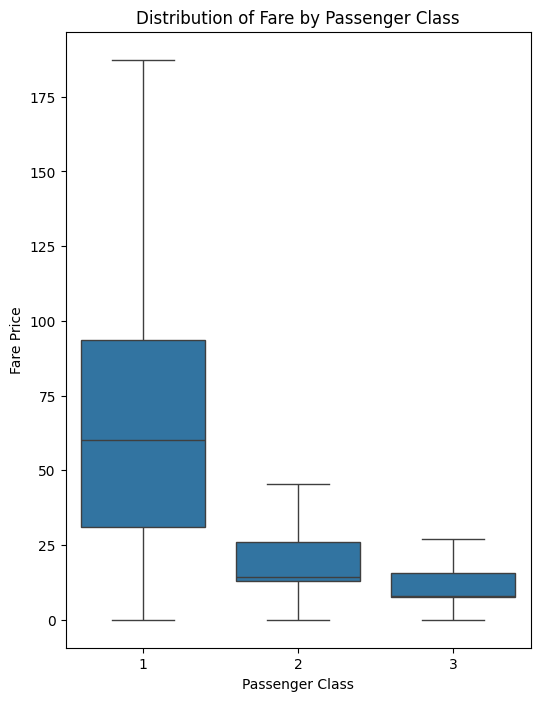

In [ ]:
# Let us plot the box plot again.

plt.figure(figsize = (6,8))
sea.boxplot(data=dataset_cap, x= 'Pclass', y='Fare')
plt.title('Distribution of Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare Price')
plt.show()

Outliers in `Age` Column

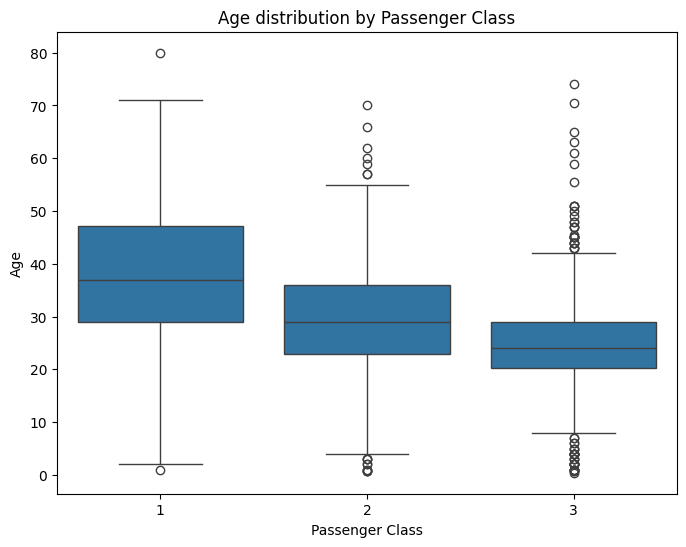

In [ ]:
plt.figure(figsize=(8,6))
sea.boxplot(data=dataset, x= 'Pclass', y='Age')
plt.title("Age distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()


In [ ]:
for pclass in dataset_cap['Pclass'].unique():
  pclass_data = dataset_cap[dataset_cap['Pclass'] == pclass]['Age']

  Q1 = pclass_data.quantile(0.25)
  Q3 = pclass_data.quantile(0.75)
  IQR = Q3 - Q1

  upper_bound = Q3 + 1.5 * IQR
  lower_bound = Q1 - 1.5 * IQR

  # Corrected: Cap 'Age' values above the upper bound
  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Age'] > upper_bound), ['Age']] = upper_bound

  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Age'] < lower_bound), ['Age']] = lower_bound

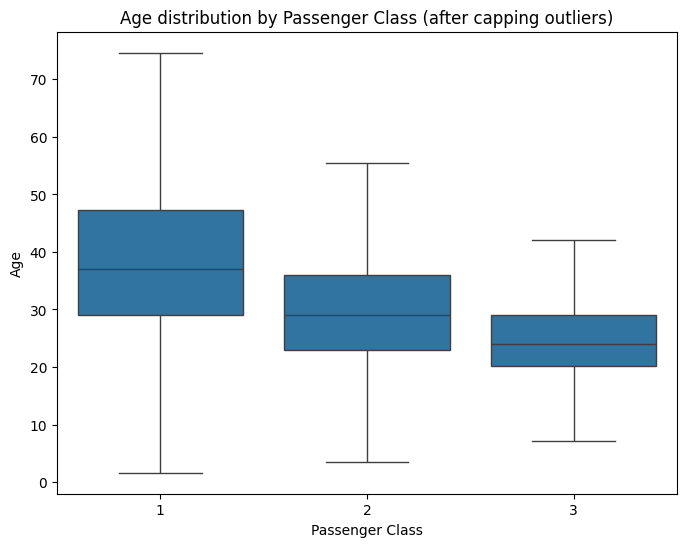

In [ ]:
plt.figure(figsize=(8,6))
sea.boxplot(data=dataset_cap, x= 'Pclass', y='Age')
plt.title("Age distribution by Passenger Class (after capping outliers)")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

Outliers in Sibling-Spouse and Parent-Child Columns

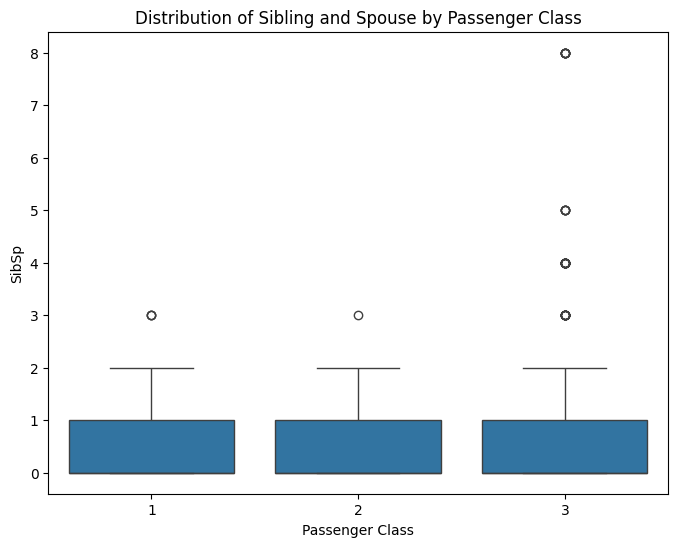

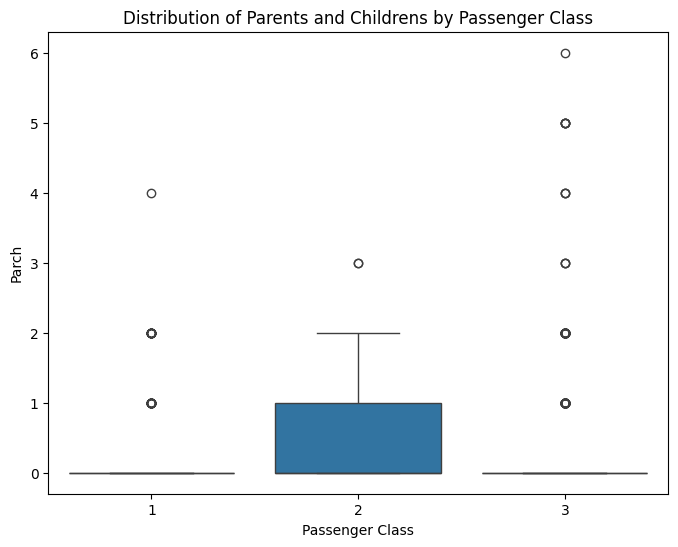

In [ ]:
plt.figure(figsize=(8,6))
sea.boxplot(data= dataset, x= 'Pclass', y='SibSp')
plt.title("Distribution of Sibling and Spouse by Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('SibSp')
plt.show()


plt.figure(figsize=(8,6))
sea.boxplot(data= dataset, x= 'Pclass', y='Parch')
plt.title("Distribution of Parents and Childrens by Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('Parch')
plt.show()

In [ ]:
# Explicitly cast 'SibSp' and 'Parch' to float to avoid FutureWarning during capping
dataset_cap['SibSp'] = dataset_cap['SibSp'].astype('float64')
dataset_cap['Parch'] = dataset_cap['Parch'].astype('float64')

for pclass in dataset_cap['Pclass'].unique():
  pclass_data = dataset_cap[dataset_cap['Pclass'] == pclass]['SibSp']

  Q1 = pclass_data.quantile(0.25)
  Q3 = pclass_data.quantile(0.75)

  IQR = Q3 - Q1

  upper_bound = Q3 + 1.5*IQR
  lower_bound = Q1 - 1.5*IQR

  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['SibSp'] > upper_bound), 'SibSp'] = upper_bound
  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['SibSp'] < lower_bound), 'SibSp'] = lower_bound

#==============================================================================

for pclass in dataset_cap['Pclass'].unique():
  pclass_data = dataset_cap[(dataset_cap['Pclass'] == pclass)]['Parch']

  Q1 = pclass_data.quantile(0.25)
  Q3= pclass_data.quantile(0.75)

  IQR = Q3 - Q1

  upper_bound = Q3 + 1.5*IQR
  lower_bound = Q1 - 1.5*IQR

  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Parch'] > upper_bound), 'Parch'] = upper_bound

  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Parch'] < lower_bound), 'Parch'] = lower_bound

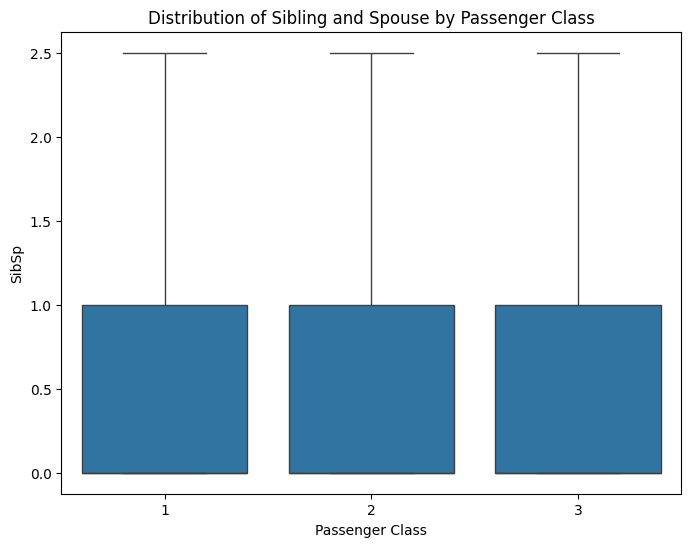

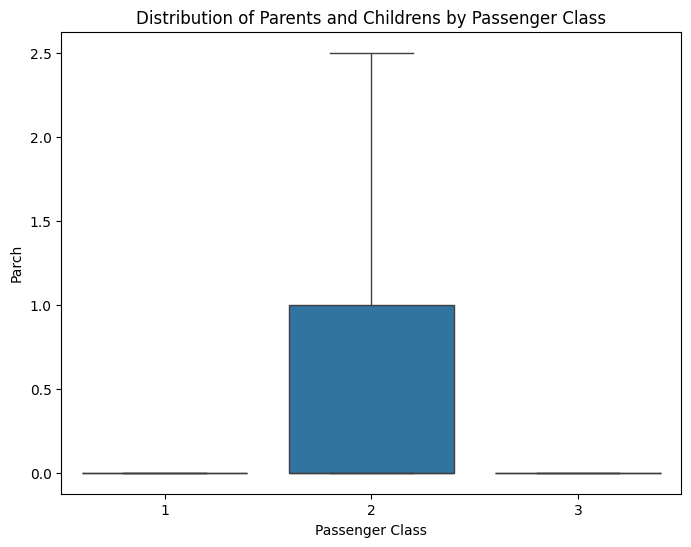

In [ ]:
plt.figure(figsize=(8,6))
sea.boxplot(data= dataset_cap, x= 'Pclass', y='SibSp')
plt.title("Distribution of Sibling and Spouse by Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('SibSp')
plt.show()


plt.figure(figsize=(8,6))
sea.boxplot(data= dataset_cap, x= 'Pclass', y='Parch')
plt.title("Distribution of Parents and Childrens by Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('Parch')
plt.show()

Now as every column is cleaned we can now perform some data analysis and find some beautiful patterns from the above data.

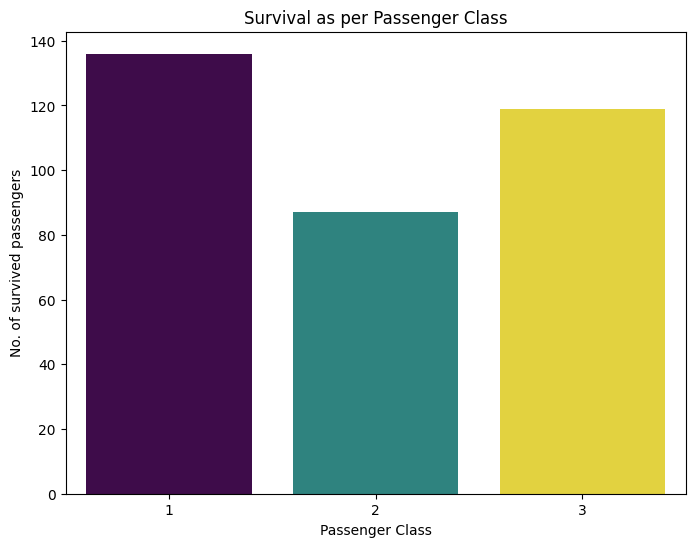

In [ ]:
# 1. Survival and Pclass Relation

survived_passenger_asper_class = dataset.groupby('Pclass')['Survived'].sum()
plt.figure(figsize=(8,6))
sea.barplot(x=survived_passenger_asper_class.index,
            y=survived_passenger_asper_class .values,
            palette='viridis', hue=survived_passenger_asper_class.index, legend=False)
plt.xlabel('Passenger Class')
plt.ylabel('No. of survived passengers')
plt.title('Survival as per Passenger Class')
plt.show()

,Survived
Sex,
female,233
male,109


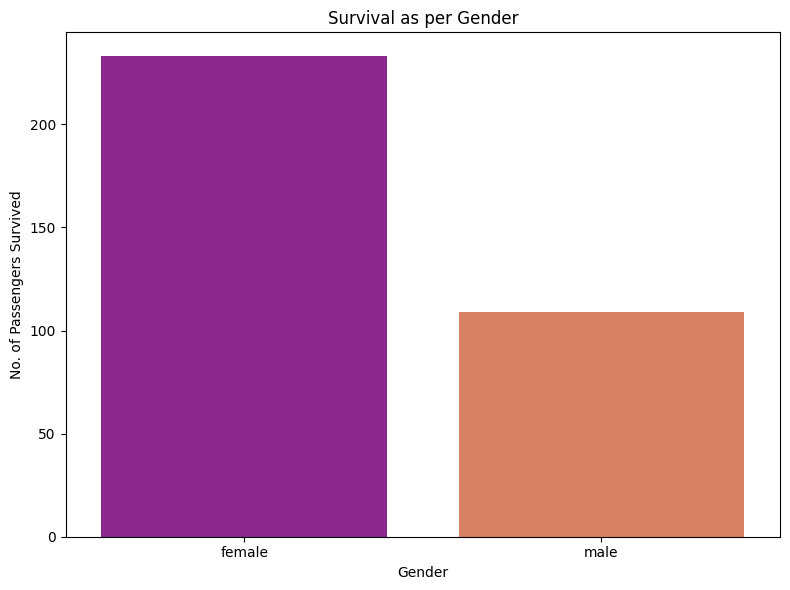

In [ ]:
survived_passengers_by_sex = dataset.groupby('Sex')['Survived'].sum()
display(survived_passengers_by_sex)

plt.figure(figsize=(8,6))
sea.barplot(x=survived_passengers_by_sex.index,
            y=survived_passengers_by_sex.values,
            palette='plasma', hue=survived_passengers_by_sex.index)
plt.title("Survival as per Gender")
plt.xlabel("Gender")
plt.ylabel("No. of Passengers Survived")
plt.tight_layout()
plt.show()

Pclass  Sex   
1       female    91
        male      45
2       female    70
        male      17
3       female    72
        male      47
Name: Survived, dtype: int64

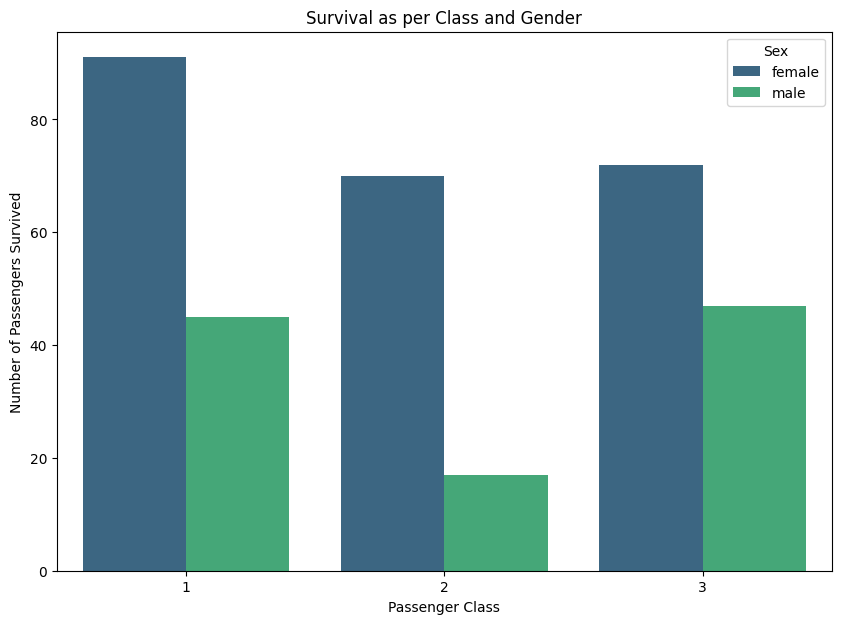

In [ ]:


# Survival as per Class and Gender
survival_class_and_gender = dataset.groupby(['Pclass', 'Sex'])['Survived'].sum()
display(survival_class_and_gender)

# Convert MultiIndex Series to DataFrame for easier plotting
survival_df = survival_class_and_gender.reset_index()

plt.figure(figsize=(10, 7))
sea.barplot(x='Pclass', y='Survived', hue='Sex', data=survival_df, palette='viridis')
plt.title('Survival as per Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers Survived')
plt.show()

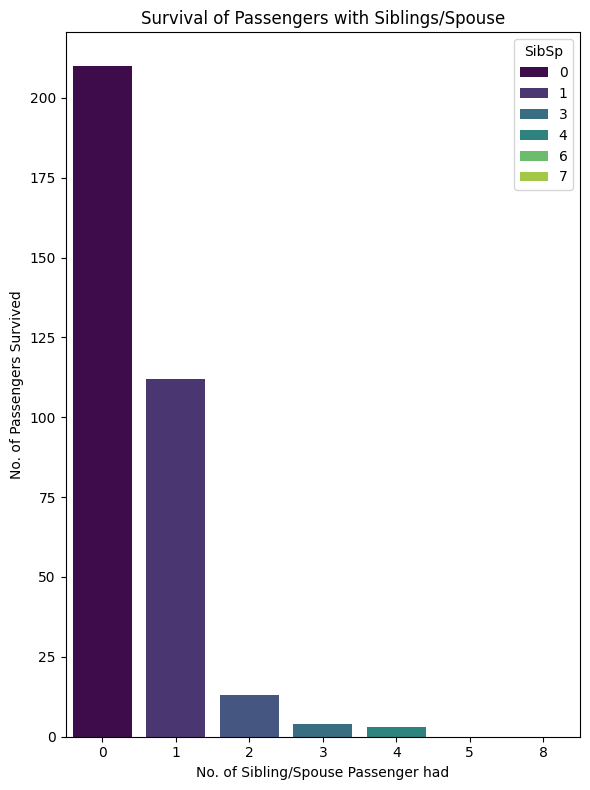

In [ ]:
sibsp_survival = dataset.groupby('SibSp')['Survived'].sum()

plt.figure(figsize=(6,8))
sea.barplot(x = sibsp_survival.index,
            y= sibsp_survival.values,
            hue= sibsp_survival.index,
            palette = 'viridis')
plt.title("Survival of Passengers with Siblings/Spouse")
plt.xlabel('No. of Sibling/Spouse Passenger had')
plt.ylabel("No. of Passengers Survived")
plt.tight_layout()
plt.show()

,Survived
Parch,
0,233
1,65
2,40
3,3
4,0
5,1
6,0


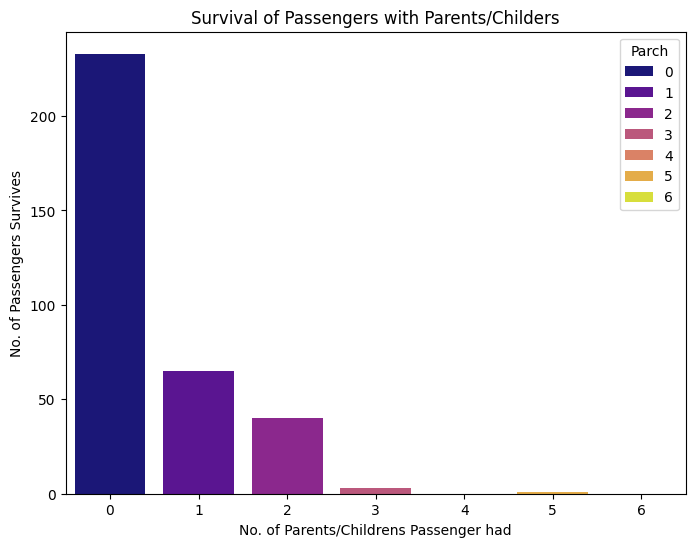

In [ ]:
parch_survival = dataset.groupby('Parch')['Survived'].sum()
display(parch_survival)
plt.figure(figsize=(8,6))
sea.barplot(x = parch_survival.index,
            y = parch_survival.values,
            hue = parch_survival.index,
            palette='plasma')
plt.title("Survival of Passengers with Parents/Childers")
plt.xlabel("No. of Parents/Childrens Passenger had")
plt.ylabel("No. of Passengers Survives")
plt.show()

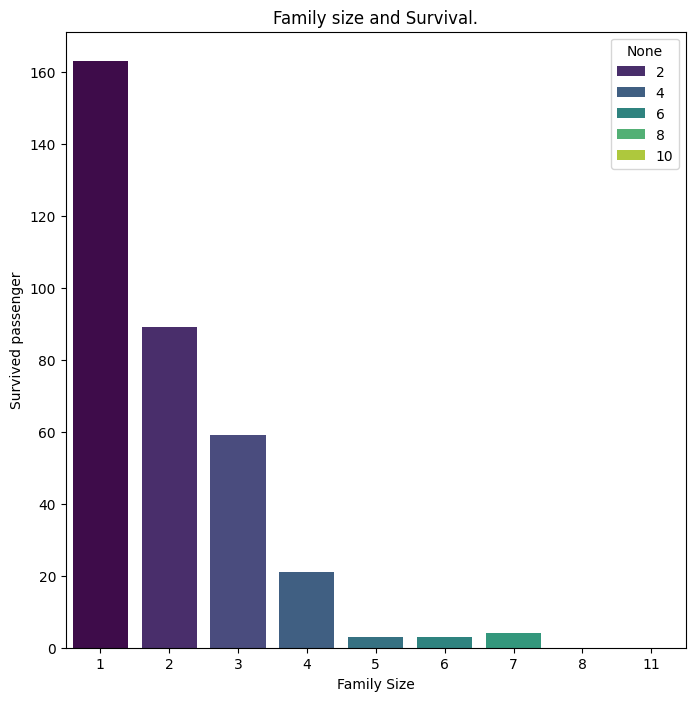

In [ ]:
# Family Size and Pclass vs Survived.

family_size = dataset['SibSp'] + dataset['Parch'] + 1
family_size_survival = dataset.groupby(family_size)['Survived'].sum()

plt.figure(figsize=(8,8))
sea.barplot(x = family_size_survival.index,
            y=family_size_survival.values, hue= family_size_survival.index, palette='viridis')
plt.title("Family size and Survival.")
plt.xlabel("Family Size")
plt.ylabel("Survived passenger")
plt.show()

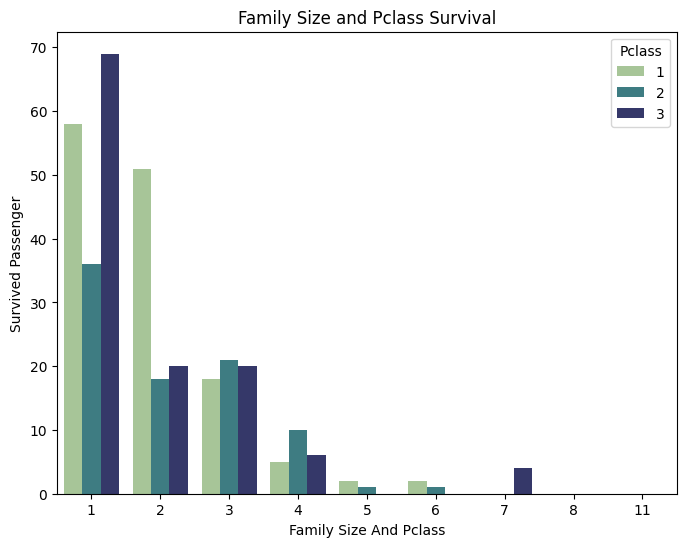

In [ ]:
family_size_per_class = dataset.groupby([family_size, 'Pclass'])['Survived'].sum()
family_size_per_class_ = family_size_per_class.reset_index()
family_size_per_class_
plt.figure(figsize=(8,6))
sea.barplot(x='level_0',
            y= 'Survived', hue='Pclass',data=family_size_per_class_, palette= 'crest')
plt.title('Family Size and Pclass Survival')
plt.xlabel("Family Size And Pclass")
plt.ylabel("Survived Passenger")
plt.show()

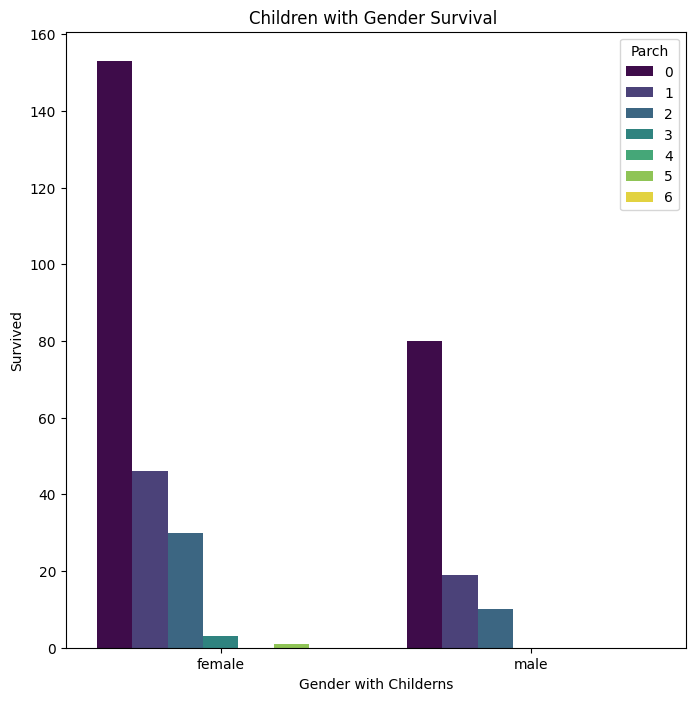

In [ ]:
#Parch and Gender.
gender_and_parch_survival = dataset.groupby(['Sex','Parch'])['Survived'].sum()

gender_and_parch_survival = gender_and_parch_survival.reset_index()

plt.figure(figsize=(8,8))
sea.barplot(x='Sex',
            y='Survived',
            hue='Parch',palette = 'viridis', data=gender_and_parch_survival)
plt.title("Children with Gender Survival ")
plt.ylabel("Survived")
plt.xlabel("Gender with Childerns")
plt.show()

In [ ]:
survived_passengers_age = dataset[dataset['Survived'] == 1]['Age']

plt.figure(figsize=(8,8))
sea.histplot(x=survived_passengers_age, kde=True) # Changed 'a' to 'x'
plt.title("Age Distribution of Survived Passengers")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

Text(0, 0.5, 'Density')

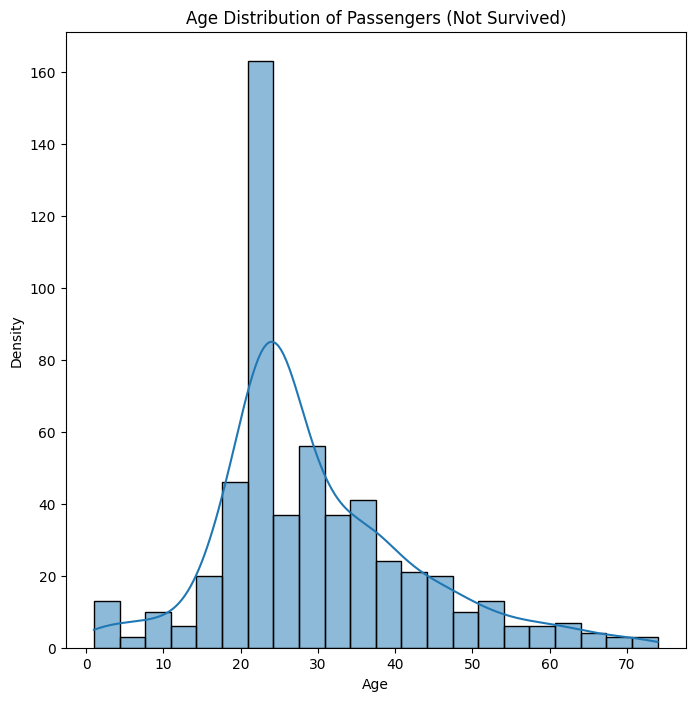

In [ ]:
not_survived_passengers_age = dataset[dataset['Survived'] == 0]['Age']

plt.figure(figsize=(8,8))
sea.histplot(x=not_survived_passengers_age, kde=True)
plt.title("Age Distribution of Passengers (Not Survived)")
plt.xlabel("Age")
plt.ylabel("Density")

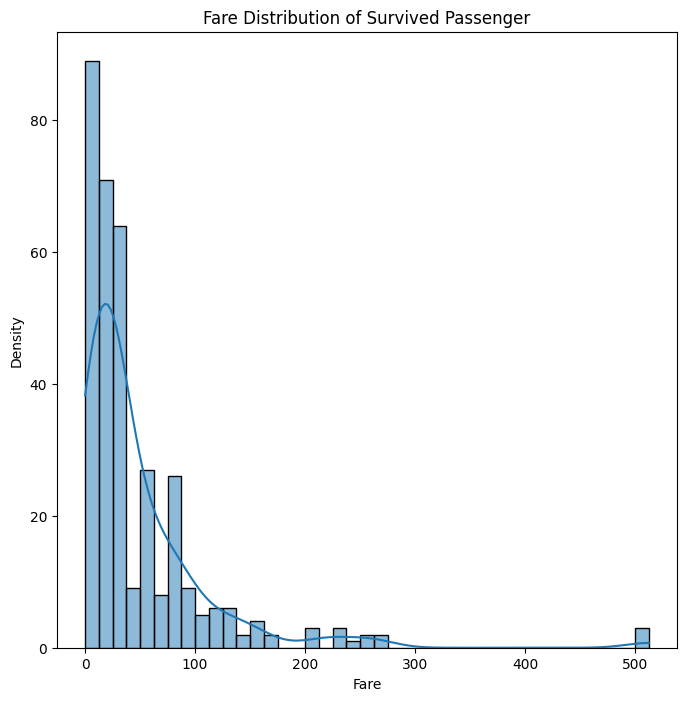

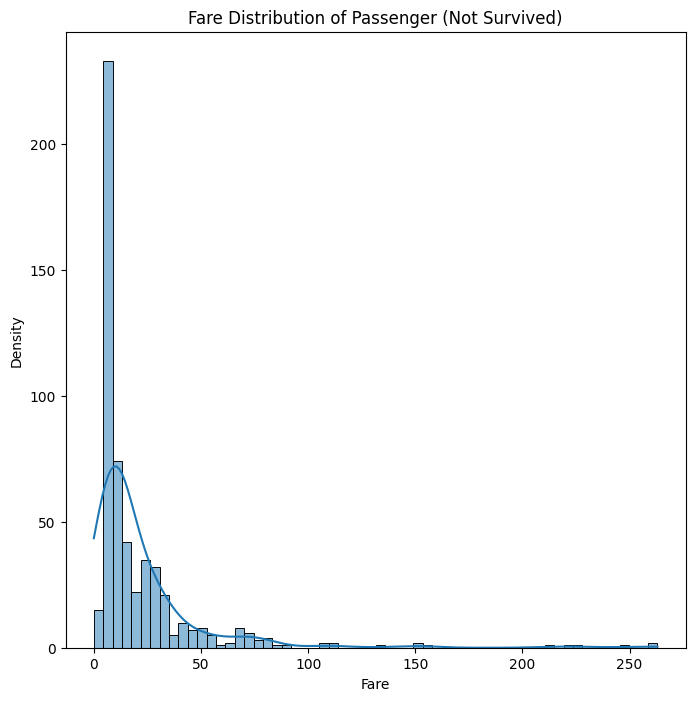

In [ ]:
# Fare Distribution
survived_passenger_fare = dataset[dataset['Survived']==1]['Fare']
not_survived_passenger_fare = dataset[dataset['Survived'] == 0]['Fare']

plt.figure(figsize=(8,8))
sea.histplot(x=survived_passenger_fare, kde=True)
plt.title("Fare Distribution of Survived Passenger")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(8,8))
sea.histplot(x=not_survived_passenger_fare, kde=True)
plt.title("Fare Distribution of Passenger (Not Survived)")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.show()

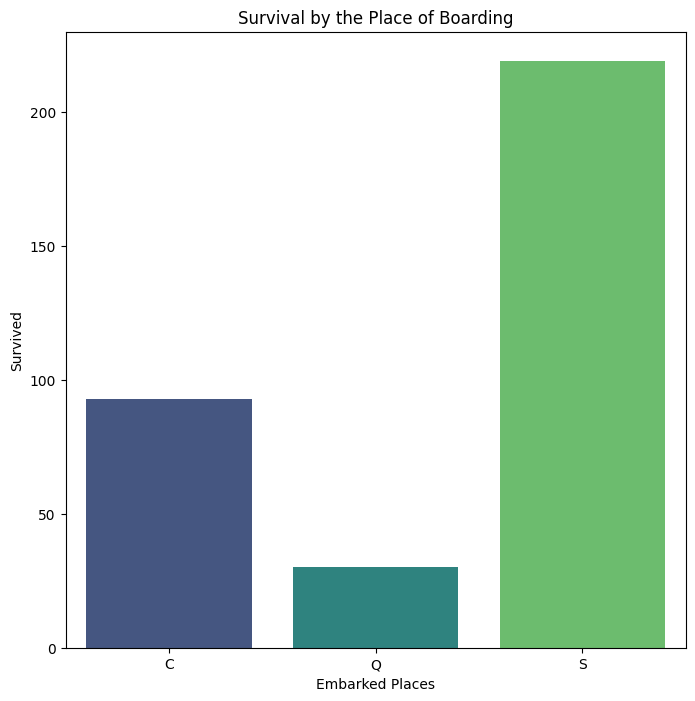

In [ ]:
embarked_place_and_survival = dataset.groupby('Embarked')['Survived'].sum()
embarked_place_and_survival = embarked_place_and_survival.reset_index()
plt.figure(figsize=(8,8))
sea.barplot(x='Embarked', y='Survived', hue='Embarked', data=embarked_place_and_survival, palette='viridis')

plt.title("Survival by the Place of Boarding")
plt.xlabel("Embarked Places")
plt.ylabel("Survived")
plt.show()

In [ ]:

numerical_features

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Prediction about what each column is about, before officially searching.

PasengerID: It is just an ID columns which tells you about the Sr.No of Passenger.

Survived: Is a boolean feature that gives 1 for survived and 0 for those who did not.


PClass: as per my knwoledge this was for what kind of passengers were there 1 for RIch and Wealthy 3 for poor and peasant type.

Name stand for Name
Sex s the gender we can analyse it also as per gender. if Male survived more or females.
Age = the age of passengers in years.

SibSp and Parch are just like Survived they are also boolean features I don't know about them yet. (no it was now a boolean feature columns)

(
  SibSp : This refers to the number of siblings or spouses travelling with each passenger abroad the Titanic.

Parch: refers to the number of Parent or childrens travelling with each passenger abroad the titanic))

Ticket is Ticket which can be identified and collected under the starting sequence order such as A/5 PC or STON this gives us idea about where the room of the passenger was allocated and all I think this is as per their affordance or how much high class can they afford to be in the ship.

Fare is i guess the amount of the ticket they had to buy it at (correct)

Cabin is there living compartment the ship had many cabins and decs so that will speicfy which cabin and deck the passenger is allocated.

Embarked: has S Q and C i think this is for standard of people No, (Emarked was the port wherwe the passenger embarked the titanic means where they boarded it, S- Southampton, C - Cherbourg and Q - QueensTown.)



Let us see what these column are actually about using Gemini to tell us.

### Accuracy of Your Initial Column Predictions (before recent edits)

Let's review how well your initial predictions aligned with the actual meanings of the Titanic dataset columns:

*   **PassengerId**: **Accurate!** You correctly identified it as a simple ID column for serial number.

*   **Survived**: **Accurate!** You correctly predicted it as a boolean feature indicating survival (1 for survived, 0 for not).

*   **Pclass**: **Highly Accurate!** Your understanding of it representing different classes (rich/wealthy vs. poor/peasant) is spot on.

*   **Name**: **Accurate!** Straightforwardly identified as the passenger's name.

*   **Sex**: **Accurate!** You correctly understood it as the gender, with potential for analysis based on male/female survival.

*   **Age**: **Accurate!** Correctly identified as the age of passengers in years.

*   **SibSp & Parch**: **Partially Accurate / Learning Moment!**
    *   You initially thought they might be boolean features, which was incorrect. However, you noted that you weren't entirely sure (`I don't know about them yet. (no it was now a boolean feature columns)`).
    *   Your later self-correction (now in parentheses) for `SibSp` (number of siblings/spouses) and `Parch` (number of parents/children) was perfectly accurate!

*   **Ticket**: **Partially Accurate!** You correctly identified it as the ticket number and even noted patterns like starting sequences (A/5, PC, STON). While you speculated about it indicating room allocation based on affordability, the primary meaning is just the ticket identifier. The connection to cabin/affordance is more indirect and sometimes inferred.

*   **Fare**: **Accurate!** You correctly guessed this was the amount paid for the ticket.

*   **Cabin**: **Accurate!** You correctly identified it as the living compartment, specifying cabin and deck allocation.

*   **Embarked**: **Partially Accurate / Learning Moment!**
    *   You initially thought it might relate to a "standard of people," which was incorrect.
    *   Your subsequent correction (now in parentheses) to "port where the passenger embarked" and mapping S, C, Q to Southampton, Cherbourg, and Queenstown respectively, was **perfectly accurate!**

Overall, your predictions were quite good, especially for the core features! Your self-corrections demonstrate a strong analytical approach to understanding the data.